In [1]:
from sklearn.datasets import load_digits
import numpy as np
import sklearn.base
import numba
import random

## Exercise 1 (Loading the dataset)

In [2]:
digits = load_digits()
data, target = digits["data"], digits["target"]
data_reduced = data[(target == 3) | (target == 8)]
target_reduced = np.zeros_like(target)
target_reduced[target == 3] = 1
target_reduced[target == 8] = -1
target_reduced = target_reduced[target_reduced != 0]

N_orig, D_orig = data_reduced.shape
data_with_bias = np.zeros((N_orig, D_orig + 1))
data_with_bias[:, :D_orig] = data_reduced
data_with_bias[:, D_orig] = 1

assert data_with_bias.shape[0] == 357, "Ex. States N=357."
assert data_with_bias.shape[1] ==  65, "Ex. States D=65"
X, y = (data_with_bias - data_with_bias.mean()) / data_with_bias.std(), target_reduced

## Exercise 1.1 (Classification with sklearn)

In [3]:
import sklearn.linear_model
import sklearn.model_selection

In [4]:
grid_search_params = {
  'C': [0.1, 0.5, 1.0, 3.0, 5.0, 10.0, 15.0, 100.0]
}
regressor = sklearn.linear_model.LogisticRegression(max_iter=300)

# Performs 5-fold-CV by default
grid_search_regressor = sklearn.model_selection.GridSearchCV(regressor, grid_search_params)
grid_search_regressor.fit(X, y);

Going to use best estimator with these params: {'C': 10.0}


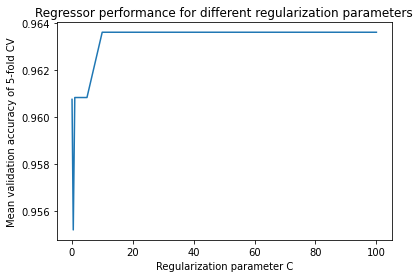

In [5]:
import matplotlib.pyplot as plt

plt.plot(
    grid_search_params['C'],
    grid_search_regressor.cv_results_['mean_test_score']
)
plt.title("Regressor performance for different regularization parameters")
plt.xlabel("Regularization parameter C")
plt.ylabel("Mean validation accuracy of 5-fold CV");
print(f'Going to use best estimator with these params: {grid_search_regressor.best_params_}')

reg_param = grid_search_regressor.best_params_['C']

In [6]:
y_pred_baseline = (grid_search_regressor.best_estimator_.predict(X) > 0)[..., np.newaxis]

## Exercise 1.2 Optimization Methods

> sigmoid(z) applies the sigmoid function to every element of the array z with σ(z) 

In [7]:
@numba.jit(nopython=True)
def sigmoid(z):
    return 1.0/(1+np.exp(-z))

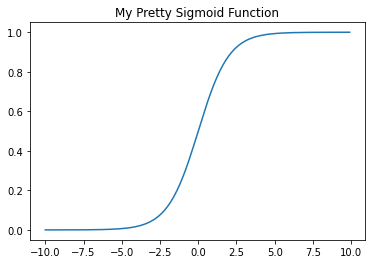

In [8]:
plt.plot(np.arange(-10,10,0.1), sigmoid(np.arange(-10, 10, 0.1)));
plt.title("My Pretty Sigmoid Function");

> gradient(beta, X, y) returns the gradient of the loss function ∇β L(β) for the given argu-
ments, where X and y are arbitrary subsets of the training data. That is, they contain a single
random instance for stochastic gradient descent, B random instances for mini-batch gradient
descent, and the full training set for standard gradient descent.

In [9]:
@numba.jit(forceobj=True)
def gradient(beta, X, y, regularization=reg_param):
    N = y.shape[0]
    sum = 0
    for i in range(N):
        sum += sigmoid(-y[i] * X[i].dot(beta)) * (-y[i] * X[i])
    return beta.T + (regularization / N) * sum


> predict(beta, X) returns a vector with one class label yi for each row Xi in X.

In [10]:
predict = lambda beta, X: np.where(X @ beta > 0, 1, -1)

> zero_one_loss(y_prediction, y_truth) counts the fraction of wrongly classified samples.2

In [11]:
zero_one_loss = lambda y_pred, y_truth: np.count_nonzero(y_pred - y_truth) / len(y_pred)

### 1) Gradient descent

In [12]:
class LogisticRegressionGradientDescent(sklearn.base.BaseEstimator):
    def __init__(
        self,
        beta_init,
        tau,
        num_iter,
    ):
        self.beta_init = beta_init
        self.tau = tau
        self.num_iter = num_iter
    
    def fit(self, X, y):
        N, M = X.shape
        beta = self.beta_init
        for epoch in range(self.num_iter):
            beta = beta - (1/N) * (self.tau * gradient(beta, X, y).squeeze())
        self.coeff_ = beta
        return self 
    
    def predict(self, X):
        return predict(self.coeff_, X)
    
    def score(self, X, y):
        return 1 - zero_one_loss(self.predict(X), y)

In [13]:
estimator = LogisticRegressionGradientDescent(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    num_iter=10
)
estimator.fit(X, y)
estimator.score(X, y)

0.9551820728291317

### 2) Stochastic Gradient Descent

In [14]:
class LogisticRegressionStochasticGradientDescent(sklearn.base.BaseEstimator):
    def __init__(
        self,
        beta_init,
        tau,
        tau_decay,
        num_iter,
        batch_size,
    ):
        self.beta_init = beta_init
        self.tau = tau
        self.tau_decay = tau_decay
        self.num_iter = num_iter
        self.batch_size = batch_size
    
    def fit(self, X, y):
        N, M = X.shape
        beta = self.beta_init
        tau = self.tau
        dataloader = list(zip(
            np.array_split(X, N // self.batch_size), 
            np.array_split(y, N // self.batch_size)
        ))
        for iteration in range(self.num_iter):
            X_batch, y_batch = random.choice(dataloader)
            #for X_batch, y_batch in dataloader:
            beta = beta - (1/N) * (tau * gradient(beta, X, y).squeeze())
            tau = (self.tau / (1 + self.tau_decay * (iteration + 1)))
        self.coeff_ = beta
        return self
    
    def predict(self, X):
        return predict(self.coeff_, X)
    
    def score(self, X, y):
        return 1 - zero_one_loss(self.predict(X), y)

In [15]:
estimator = LogisticRegressionStochasticGradientDescent(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    tau_decay=0.01,
    num_iter=150,
    batch_size=1,
)
estimator.fit(X, y)
estimator.score(X, y)

0.9551820728291317

## SG Momentum:

In [16]:
class LogisticRegressionSGMomentum(sklearn.base.BaseEstimator):
    def __init__(
        self,
        beta_init,
        tau,
        tau_decay,
        num_iter,
        momentum,
    ):
        self.beta_init = beta_init
        self.tau = tau
        self.tau_decay = tau_decay
        self.num_iter = num_iter
        self.momentum = momentum
    
    def fit(self, X, y):
        N, M = X.shape
        g = np.zeros((M))
        beta = self.beta_init       
        tau = self.tau

        for iteration in range(self.num_iter):
            sample_idx = np.random.randint(low=0, high=len(X))
            X_sample = X[sample_idx, :][np.newaxis, ...]
            y_sample = np.array([y[sample_idx]])
            g = self.momentum * g + (1 - self.momentum) * gradient(beta, X_sample, y_sample)
            beta = beta - tau * g
            tau = (self.tau / (1 + self.tau_decay * (iteration + 1)))

        self.coeff_ = beta
        return self
    
    def predict(self, X):
        return predict(self.coeff_, X)
    
    def score(self, X, y):
        return 1 - zero_one_loss(self.predict(X), y)

In [17]:
estimator = LogisticRegressionSGMomentum(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    tau_decay=0.01,
    num_iter=150,
    momentum=0.001,
)
estimator.fit(X, y)
estimator.score(X, y)

0.8599439775910365

## ADAM:

In [18]:
class LogisticRegressionAdam(sklearn.base.BaseEstimator):
    def __init__(
        self,
        beta_init,
        tau,
        tau_decay,
        num_iter,
        mu_1,
        mu_2,
        epsilon,
    ):
        self.beta_init = beta_init
        self.tau = tau
        self.tau_decay = tau_decay
        self.num_iter = num_iter
        self.mu_1 = mu_1
        self.mu_2 = mu_2
        self.epsilon = epsilon

    
    def fit(self, X, y):
        N, M = X.shape
        g = np.zeros((M))
        q = np.zeros((M))
        beta = self.beta_init
        tau = self.tau
        for iteration in range(self.num_iter):
            sample_idx = np.random.randint(low=0, high=len(X))
            X_sample = X[sample_idx, :][np.newaxis, ...]
            y_sample = np.array([y[sample_idx]])

            grad = gradient(beta, X_sample, y_sample)
            g = self.mu_1 * g + (1 - self.mu_1) * grad
            q = self.mu_2 * q + (1 - self.mu_2) * (grad ** 2)
            g_tilde = (g / (1 - self.mu_1 ** (iteration+1)))
            q_tilde = (q / (1 - self.mu_2 ** (iteration+1)))
            beta = beta - (tau / (np.sqrt(q_tilde) + self.epsilon)) * g_tilde
            tau = (self.tau / (1 + self.tau_decay * (iteration + 1)))
        self.coeff_ = beta
        return self
    
    def predict(self, X):
        return predict(self.coeff_, X)
    
    def score(self, X, y):
        return 1 - zero_one_loss(self.predict(X), y)

In [19]:
estimator = LogisticRegressionAdam(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    tau_decay=0.01,
    num_iter=150,
    mu_1=0.9,
    mu_2=0.999,
    epsilon=10e-8
)
estimator.fit(X, y)
estimator.score(X, y)

0.5910364145658263

## Stoachastic average gradient:

In [20]:
class LogisticRegressionSAG(sklearn.base.BaseEstimator):
    def __init__(
        self,
        beta_init,
        tau,
        tau_decay,
        num_iter,
        regularizer,
    ):
        self.beta_init = beta_init
        self.tau = tau
        self.tau_decay = tau_decay
        self.num_iter = num_iter
        self.regularizer = regularizer

    
    def fit(self, X, y):
        N, M = X.shape
        beta = self.beta_init
        g_stored = np.array([-y[i] * X[i].T * sigmoid(-y[i] * X[i].dot(beta)) for i in range(y.shape[0])])
        g = (1 / N) * np.sum(g_stored, axis=0)
        tau = self.tau
        for iteration in range(self.num_iter):
            sample_idx = np.random.randint(low=0, high=len(X))

            g_i = -y[sample_idx] * X[sample_idx] * sigmoid(-y[sample_idx]*np.dot(X[sample_idx],beta))
            g = g + (1 / N) * (g_i - g_stored[sample_idx])
            g_stored[sample_idx, :] = g_i
            beta = beta * (1 - (tau / self.regularizer)) - tau * g
            tau = (self.tau / (1 + self.tau_decay * (iteration + 1)))
        self.coeff_ = beta
        return self
    
    def predict(self, X):
        return predict(self.coeff_, X)
    
    def score(self, X, y):
        return 1 - zero_one_loss(self.predict(X), y)

In [21]:
estimator = LogisticRegressionSAG(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    tau_decay=0.01,
    num_iter=150,
    regularizer=1,
)
estimator.fit(X, y)
estimator.score(X, y)


0.9551820728291317

## Dual coordinate ascent

In [22]:
class LogisticRegressionDualCoordAscent(sklearn.base.BaseEstimator):
    def __init__(
        self,
        alpha_init,
        num_iter,
        regularizer,
        epsilon
    ):
        self.alpha_init = alpha_init
        self.num_iter = num_iter
        self.regularizer = regularizer
        self.epsilon = epsilon
    
    def fit(self, X, y):
        N, M = X.shape
        alpha = self.alpha_init
        reg_param = self.regularizer
        beta = reg_param/N * np.sum(np.array([alpha[i]*y[i]*X[i].T for i in range(N)]), axis=0)
        for _ in range(self.num_iter):
            sample_idx = np.random.randint(low=0, high=len(X))
            f_first = (y[sample_idx] * np.dot(X[sample_idx],beta)) + np.log(alpha[sample_idx]/(1-alpha[sample_idx]))
            f_second = (reg_param / N) * np.dot(X[sample_idx], X[sample_idx].T) + 1/(alpha[sample_idx]*(1-alpha[sample_idx]))
            alpha_prev = alpha[sample_idx]
            alpha[sample_idx] = np.clip(alpha[sample_idx] - (f_first/f_second), self.epsilon, 1 - self.epsilon)
            beta = beta + (reg_param / N) * y[sample_idx] * X[sample_idx].T * (alpha[sample_idx] - alpha_prev)
        self.coeff_ = beta
        return self
    
    def predict(self, X):
        return predict(self.coeff_, X)
    
    def score(self, X, y):
        return 1 - zero_one_loss(self.predict(X), y)

In [23]:
estimator = LogisticRegressionDualCoordAscent(
    alpha_init=np.random.uniform(0, 1, X.shape[0]),
    num_iter=150,
    regularizer=1,
    epsilon=0.001,
)
estimator.fit(X, y)
estimator.score(X, y)

0.9551820728291317

## Newton/Raphson

In [24]:
class LogisticRegressionNewtonRaphson(sklearn.base.BaseEstimator):
    def __init__(
        self,
        beta_init,
        num_iter,
        regularizer,
    ):
        self.beta_init = beta_init
        self.num_iter = num_iter
        self.regularizer = regularizer
    
    def fit(self, X, y):
        N, M = X.shape
        beta = self.beta_init
        for iter in range(self.num_iter):
            scores = X@beta
            weighted_labels = (y / sigmoid(y * scores.flatten()))
            W=np.diag(((self.regularizer/N) * sigmoid(scores) * sigmoid(-scores)).flatten())
            beta = np.linalg.pinv(np.identity(M) + (X.T@W@X))@X.T@W@(scores.flatten()+weighted_labels)        
        self.coeff_ = beta
        return self
    
    def predict(self, X):
        return predict(self.coeff_, X)
    
    def score(self, X, y):
        return 1 - zero_one_loss(self.predict(X), y)

In [25]:
estimator = LogisticRegressionNewtonRaphson(
    beta_init=np.zeros((X.shape[1])),
    num_iter=10,
    regularizer=1,
)
estimator.fit(X, y)
estimator.score(X, y)

0.9775910364145658

# Comparison

In [26]:
params = {
  'tau': [0.001, 0.01, 0.1],
  'momentum': [0.1, 0.2, 0.5],
  'tau_decay': [0.0001, 0.001, 0.01],
}

In [27]:
estimator_gd = LogisticRegressionGradientDescent(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    num_iter=10
)
estimator_sgd = LogisticRegressionStochasticGradientDescent(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    tau_decay=0.01,
    num_iter=150,
    batch_size=1,
)
estimator_sgd_minibatch = LogisticRegressionStochasticGradientDescent(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    tau_decay=0.01,
    num_iter=150,
    batch_size=8,
)
estimator_sg_momentum = LogisticRegressionSGMomentum(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    tau_decay=0.01,
    num_iter=150,
    momentum=0.001,
)
estimator_adam = LogisticRegressionAdam(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    tau_decay=0.01,
    num_iter=150,
    mu_1=0.9,
    mu_2=0.999,
    epsilon=10e-8
)
estimator_sag = LogisticRegressionSAG(
    beta_init=np.zeros(X.shape[1]),
    tau=1e-4,
    tau_decay=0.01,
    num_iter=150,
    regularizer=reg_param,
)
estimator_dca = LogisticRegressionDualCoordAscent(
    alpha_init=np.random.uniform(0, 1, X.shape[0]),
    num_iter=150,
    regularizer=reg_param,
    epsilon=0.001,
)
estimator_newton = LogisticRegressionNewtonRaphson(
    beta_init=np.zeros((X.shape[1])),
    num_iter=10,
    regularizer=reg_param,
)

estimators = [
    estimator_gd,
    estimator_sgd,
    estimator_sgd_minibatch,
    estimator_sg_momentum,
    estimator_adam,
    estimator_sag,
    estimator_dca,
    estimator_newton
]
estimator_names = ["GD", "SGD", "SGD/B", "SGM", "ADAM", "SAG", "DCA", "Newton"]

In [28]:
cv_results = []
for estimator in estimators:
    params_specific = {
        k: v for k, v in params.items() if k in estimator.get_params()}
    grid_search_regressor = sklearn.model_selection.GridSearchCV(
        estimator, params_specific, cv=10)
    grid_search_regressor.fit(X, y)
    cv_results.append(grid_search_regressor)

In [29]:
scores = [result.cv_results_['mean_test_score'] for result in cv_results]

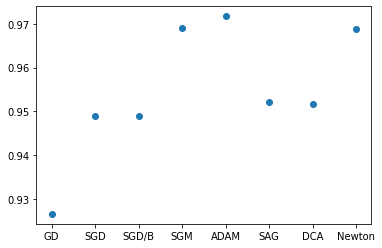

In [30]:
best_scores = [result.best_score_ for result in cv_results]
plt.scatter(estimator_names ,best_scores);

In [31]:
for name, result in zip(estimator_names, cv_results):
    r = result.best_estimator_.get_params()
    best = {k:v for k, v in r.items() if k in params}
    print(f'{name}\t\tBest:\t{best}')

GD		Best:	{'tau': 0.1}
SGD		Best:	{'tau': 0.1, 'tau_decay': 0.0001}
SGD/B		Best:	{'tau': 0.1, 'tau_decay': 0.0001}
SGM		Best:	{'momentum': 0.5, 'tau': 0.01, 'tau_decay': 0.001}
ADAM		Best:	{'tau': 0.01, 'tau_decay': 0.001}
SAG		Best:	{'tau': 0.1, 'tau_decay': 0.01}
DCA		Best:	{}
Newton		Best:	{}


## Speed

In [32]:
from sklearn import model_selection
X, X_test, y, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=0)

In [33]:
N, D = X.shape
O_GD = lambda T: T*N*D
O_SGD_BATCH = lambda T: 8*D*T
O_STOCHASTIC = lambda T: D*T
O_NEWTON = lambda T: T*N*D**2

complexities = [
  O_GD,
  O_STOCHASTIC,
  O_SGD_BATCH,
  O_STOCHASTIC,
  O_STOCHASTIC,
  O_STOCHASTIC,
  O_STOCHASTIC,
  O_NEWTON
]

iterations = [1, 2, 3, 4, 5, 10, 20, 30, 50, 60, 80, 100, 200, 400]

alg_convergence_results = []
for name, complexity, result in zip(estimator_names, complexities, cv_results):
    alg_results = []
    best_estimator = result.best_estimator_
    
    for T in iterations:
        best_estimator.set_params(num_iter=T)
        best_estimator.fit(X, y)
        train_error = 1 - best_estimator.score(X, y)
        test_error = 1 - best_estimator.score(X_test, y_test)
        runtime_estimate = complexity(T)
        alg_results.append([runtime_estimate, train_error, test_error])
    alg_convergence_results.append(alg_results)
alg_convergence_results = np.array(alg_convergence_results)

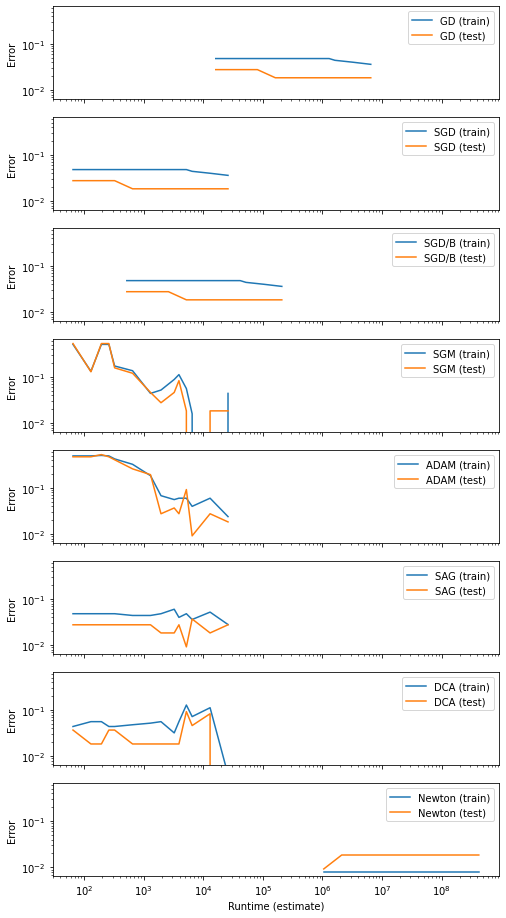

In [34]:
fig, ax = plt.subplots(len(estimator_names), sharex=True, sharey=True)
fig.set_size_inches(8, len(estimator_names)*2)
[a.set_yscale('log') for a in ax.flat]
[a.set_xscale('log') for a in ax.flat]
for i, name in enumerate(estimator_names):
    res = alg_convergence_results[i, :, :]
    ax[i].plot(res[:, 0], res[:, 1], label=f'{name} (train)')
    ax[i].plot(res[:, 0], res[:, 2], label=f'{name} (test)')
    ax[i].legend()
    ax[i].set_ylabel("Error")
plt.grid(False)
plt.xlabel("Runtime (estimate)");

> Which of the algorithms is the fastest to
converge?

We find that Stochastic Average Gradient (SAG) is the fastest, with Stochastic Gradient Descent (batch-size=1) being a close second.

> Are there qualitative differences between methods?

Yes!

* GD, SGD, and SGD w/ Minibatch exhibit "true" convergence behavior: once they found the (global in this case) minimum, they stay there.
* SGM, ADAM, and DCA converge quickly but there seems to be an ideal number of iterations for optimal test error.
* Newton converges immediately, and notably achieves a slightly better test error than other methods, but is very expensive.